# Tyre Strategies

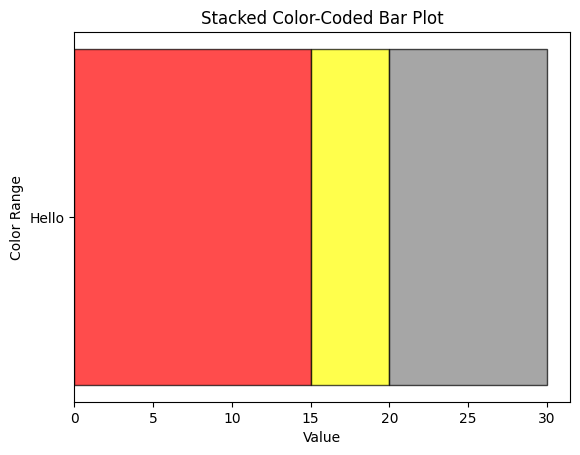

In [1]:
import matplotlib.pyplot as plt

# Define your list of tuples
data = [(0, 'RED'), (15, 'YELLOW'), (20, 'GREY')]

# Extract the colors and their corresponding ranges
colors = [color for _, color in data]
ranges = [range_end for range_end, _ in data]

# Add an upper limit to the last range
ranges.append(30)

# Plot the stacked horizontal bar chart
# plt.figure(figsize=(8, 3))  # Adjust figure size as needed

bottom = 0
for i in range(len(ranges)-1):
    plt.barh(y=["Hello"], width=ranges[i+1]-ranges[i], left=ranges[i], color=colors[i], label=f'{ranges[i]}-{ranges[i+1]}', edgecolor='black', height=0.5, alpha=0.7)
    bottom += ranges[i+1]-ranges[i]

# Customize the plot
plt.xlabel('Value')
plt.ylabel('Color Range')
plt.title('Stacked Color-Coded Bar Plot')

# Show the plot
plt.show()


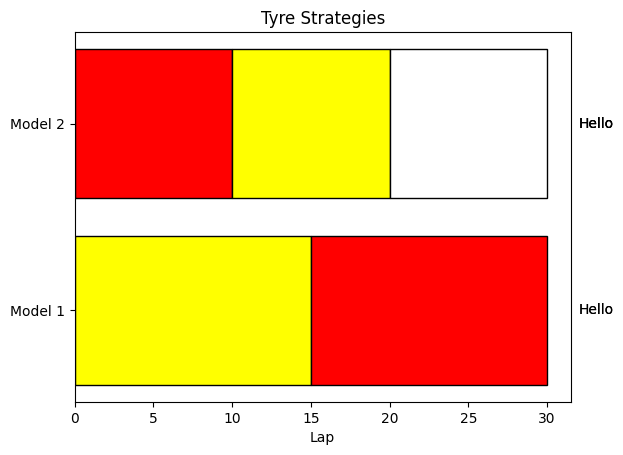

In [2]:
import matplotlib.pyplot as plt

def plot_stacked_bars(name, data):
    # Extract the colors and their corresponding ranges
    colors = [color for _, color in data]
    ranges = [range_end for range_end, _ in data]

    # Add an upper limit to the last range
    ranges.append(30)

    # Plot the stacked horizontal bar chart
    for i in range(len(ranges)-1):
        plt.barh(y=name, width=ranges[i+1]-ranges[i], left=ranges[i], color=colors[i], label=f'{ranges[i]}-{ranges[i+1]}', edgecolor='black')
        plt.text(ranges[-1] + 2, y=name, s='Hello', ha='left', va='center')


# Define your list of datasets
datasets = [
    ("Model 1", [(0, 'YELLOW'), (15, 'RED')]),
    ("Model 2", [(0, 'RED'), (10, 'YELLOW'), (20, 'WHITE')]),
]

# Plot the stacked horizontal bar chart for each dataset
for name, data in datasets:
    plot_stacked_bars(name, data)

# Customize the plot
plt.xlabel('Lap')
plt.title('Tyre Strategies')

# Show the plot
plt.show()


# No Tyre Degradation Laptime Loss

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


-------------------- SIMULATION DETAILS --------------------
Track: BAHRAIN 2023
Total Laps: 57
Seed: 360
Selected Driver: 44
Restricted Years: ['2023']
Restricted Tracks: [BAHRAIN]
------------------------------------------------------------
UnifiedRaceState[R BAHRAIN CAT1 2023 NSC P14 SP0.684  PP5  PF14 L1.32  L%2   PS0  S TD0.012  STD0.001  T%4   SL2.0  SSL0.020  [S] [M] [H] F106.453 FC1.910  ND GA0.712   SGA0.024  GB1.028   SGB0.034  GL9.405   SGL-0.657 LL110.158  RL96.439  LT%114 SLT0.13 NV ]
NO_PIT UnifiedRaceState[R BAHRAIN CAT1 2023 NSC P14 SP0.684  PP5  PF14 L2.32  L%4   PS0  S TD0.240  STD0.012  T%5   SL3.0  SSL0.030  [S] [M] [H] F104.543 FC1.910  ND GA0.839   SGA0.028  GB1.370   SGB0.046  GL11.666  SGL-0.638 LL99.172   RL96.439  LT%102 SLT0.03 NV ]
NO_PIT UnifiedRaceState[R BAHRAIN CAT1 2023 NSC P14 SP0.684  PP5  PF14 L3.32  L%5   PS0  S TD0.469  STD0.023  T%7   SL4.0  SSL0.040  [S] [M] [H] F102.633 FC1.910  ND GA0.880   SGA0.029  GB1.075   SGB0.036  GL13.672  SGL-0.620 LL99

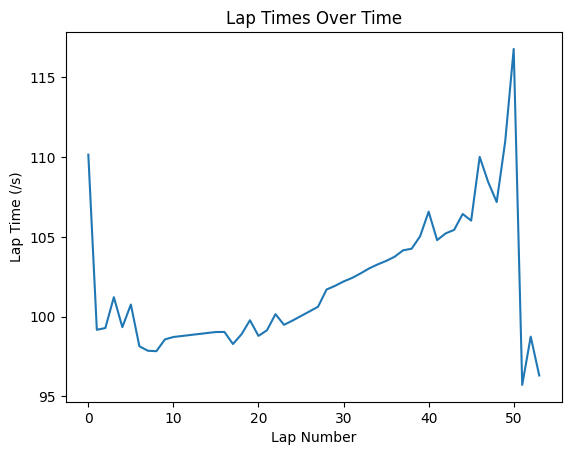

In [ ]:
import numpy as np
from Classes.RaceStrategy.SimpleRaceStrategy import SimpleRaceStrategy
from Models.StrategyRLModel import StrategyRLModel
from Classes.Enums import Track
from confidential.MercedesRSTranslator import MercedesRSTranslator
from Models.MercedesProbabilisticModel import MercedesLinearModel
import matplotlib.pyplot as plt

# model = StrategyRLModel.load_model("Saved Models/DQN Long Train/dqn_model_8000.pth")
model = MercedesLinearModel(selected_driver=44)

sim = MercedesRSTranslator(
    selected_driver=44,
    seed=360,
    allowed_years=["2023"],
    allowed_tracks=[Track.BAHRAIN],
    disable_safety_car=False,
    verbose=True,
)
sim.initialise_random_simulation()

lap_times = []

state = sim.step(step=1)
print(state)
while not state.terminal:
    lap_times.append(state.last_lap_time)
    # action = model.predict(state)
    action = SimpleRaceStrategy.PIT_HARD if int(state.partial_lap_number) == 49 else SimpleRaceStrategy.NO_PIT
    state = sim.step(step=1.0, strategy=action)
    print(action, state)

plt.plot(lap_times)
plt.xlabel("Lap Number")
plt.ylabel("Lap Time (/s)")
plt.title("Lap Times Over Time")
plt.show()

sim.plot_race()

# Feature Plots

In [4]:
from Classes.Enums import Track
from Classes.RaceStrategy.SimpleRaceStrategy import SimpleRaceStrategy
from confidential.MercedesRSTranslator import MercedesRSTranslator
import matplotlib.pyplot as plt

sim = MercedesRSTranslator(
    selected_driver=44,
    seed=3,
    allowed_years=["2023"],
    allowed_tracks=[Track.BAHRAIN],
    disable_safety_car=False,
    verbose=True,
)
_, state = sim.initialise_random_simulation()

states = [] 
while not state.terminal:
    action = SimpleRaceStrategy.PIT_MEDIUM if 49 < state.partial_lap_number <= 50 else SimpleRaceStrategy.NO_PIT
    state = sim.step(step=1.0, strategy=action)
    states.append(state)
    print(action, state)

-------------------- SIMULATION DETAILS --------------------
Track: BAHRAIN 2023
Total Laps: 57
Seed: 3
Selected Driver: 44
Restricted Years: ['2023']
Restricted Tracks: [BAHRAIN]
------------------------------------------------------------
NO_PIT UnifiedRaceState[R BAHRAIN CAT1 2023 NSC P2  SP0.053  PP5  PF2  L1.32  L%2   PS0  S TD0.001  STD0.000  T%4   SL2.0  SSL0.020  [S] [M] [H] F106.453 FC1.910  ND GA1.249   SGA0.042  GB1.034   SGB0.034  GL1.249   SGL-0.728 LL101.785  RL96.439  LT%105 SLT0.05 NV ]
NO_PIT UnifiedRaceState[R BAHRAIN CAT1 2023 NSC P2  SP0.053  PP5  PF2  L2.32  L%4   PS0  S TD0.113  STD0.006  T%5   SL3.0  SSL0.030  [S] [M] [H] F104.543 FC1.910  ND GA2.233   SGA0.074  GB1.527   SGB0.051  GL2.233   SGL-0.720 LL97.345   RL96.439  LT%100 SLT0.01 NV ]
NO_PIT UnifiedRaceState[R BAHRAIN CAT1 2023 NSC P2  SP0.053  PP5  PF2  L3.32  L%5   PS0  S TD0.244  STD0.012  T%7   SL4.0  SSL0.040  [S] [M] [H] F102.633 FC1.910  ND GA3.211   SGA0.107  GB2.017   SGB0.067  GL3.211   SGL-0.711

In [5]:
def plot_two_graphs(graph1, graph2, title1, title2):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(20, 8)

    partial_lap_numbers = [state.partial_lap_number for state in states]

    ax1.plot(partial_lap_numbers, graph1)
    ax1.set_title(title1)

    ax2.plot(partial_lap_numbers, graph2)
    ax2.set_title(title2)

    plt.show()

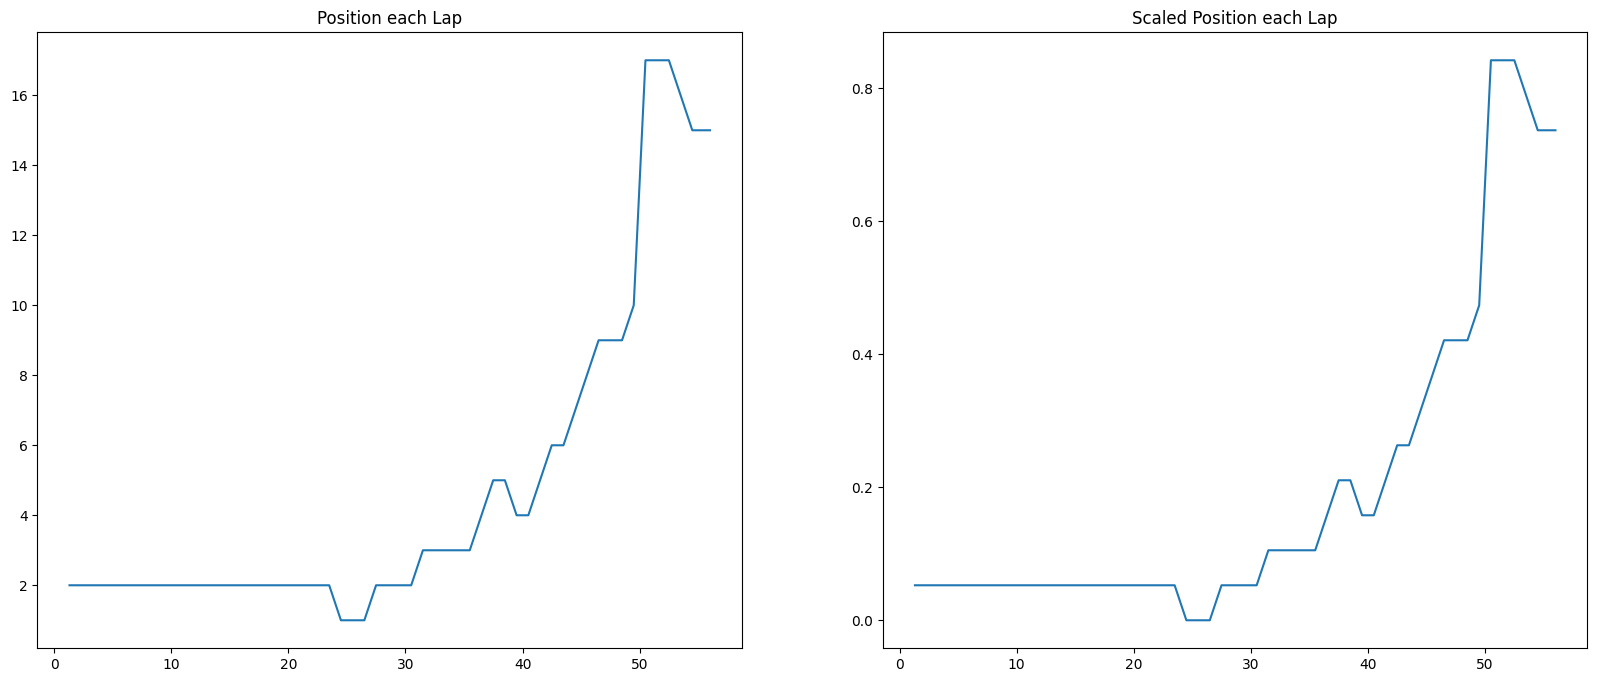

In [6]:
positions = [state.position for state in states]
scaled_positions = [state.scaled_position for state in states]

plot_two_graphs(positions, scaled_positions, "Position each Lap", "Scaled Position each Lap")

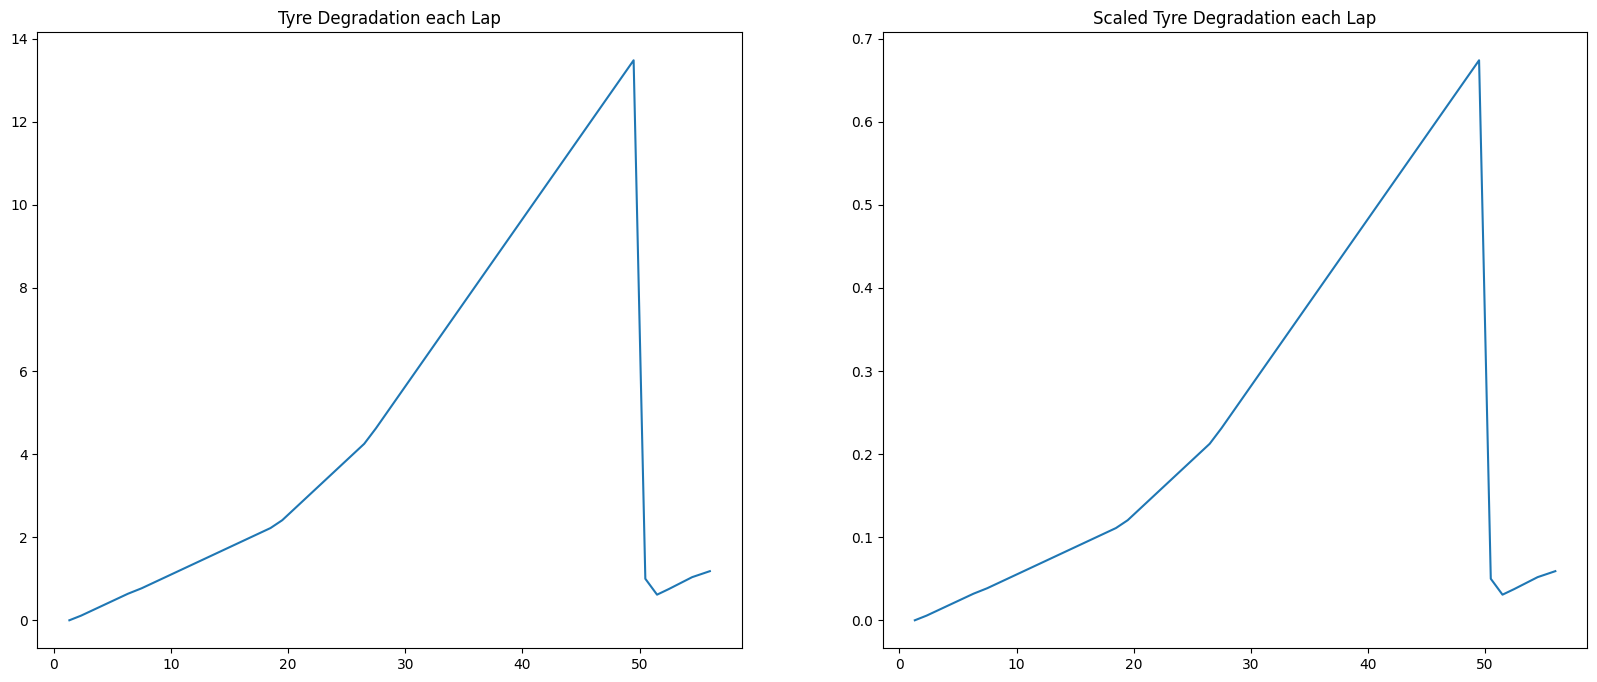

In [7]:
tyre_degradations = [state.tyre_degradation for state in states]
scaled_tyre_degradations = [state.scaled_tyre_degradation for state in states]

plot_two_graphs(tyre_degradations, scaled_tyre_degradations, "Tyre Degradation each Lap", "Scaled Tyre Degradation each Lap")

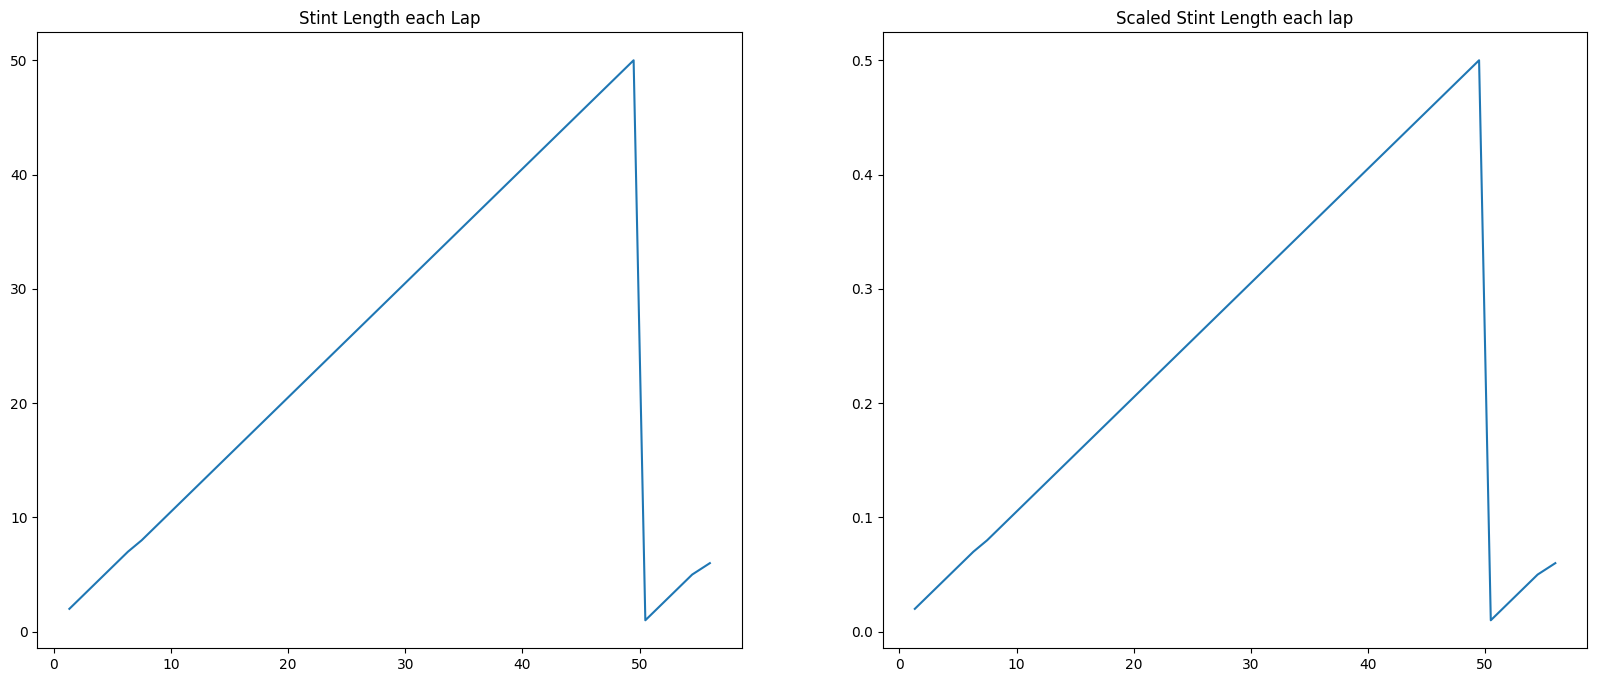

In [8]:
stint_lengths = [state.stint_length for state in states]
scaled_stint_lengths = [state.scaled_stint_length for state in states]

plot_two_graphs(stint_lengths, scaled_stint_lengths, "Stint Length each Lap", "Scaled Stint Length each lap")

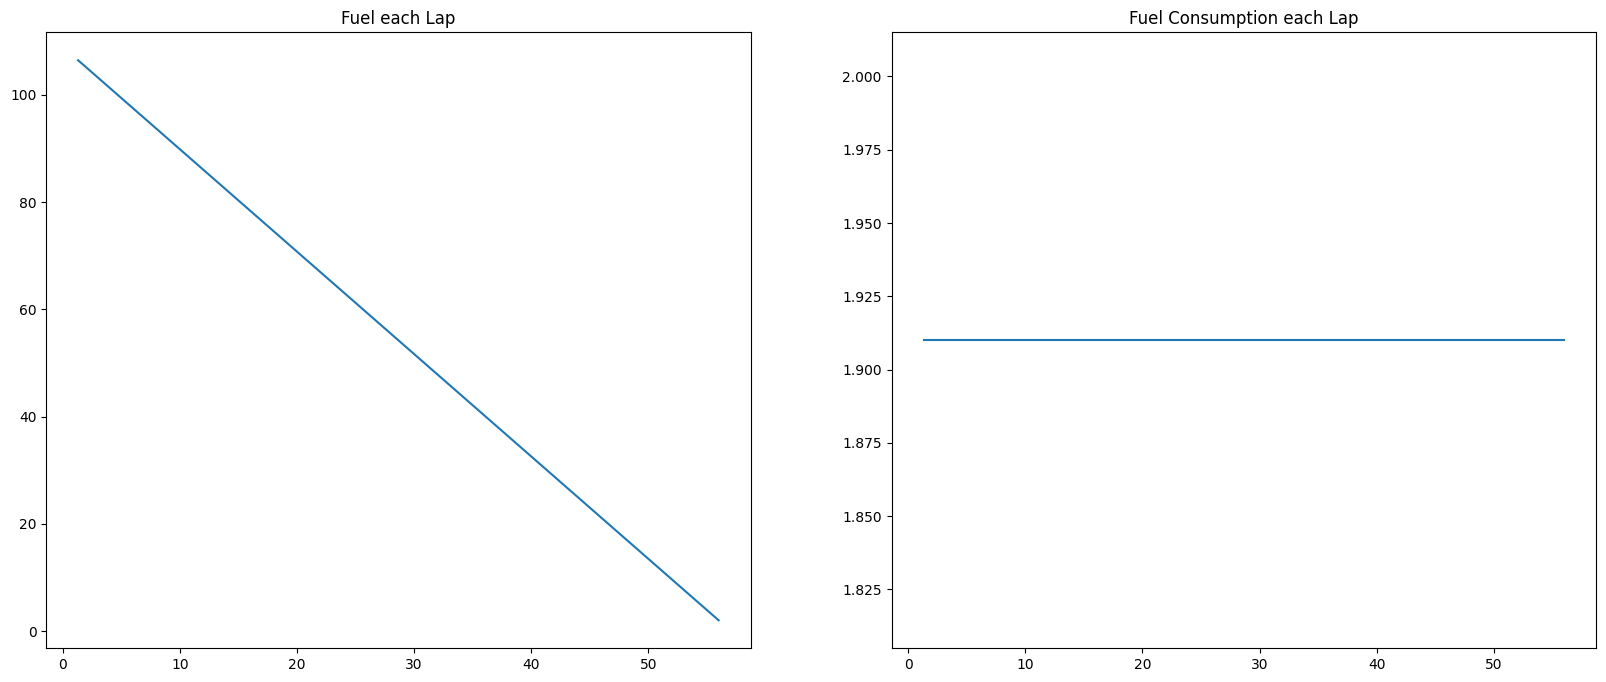

In [9]:
fuels = [state.fuel for state in states]
fuel_consumptions = [state.fuel_consumption for state in states]

plot_two_graphs(fuels, fuel_consumptions, "Fuel each Lap", "Fuel Consumption each Lap")

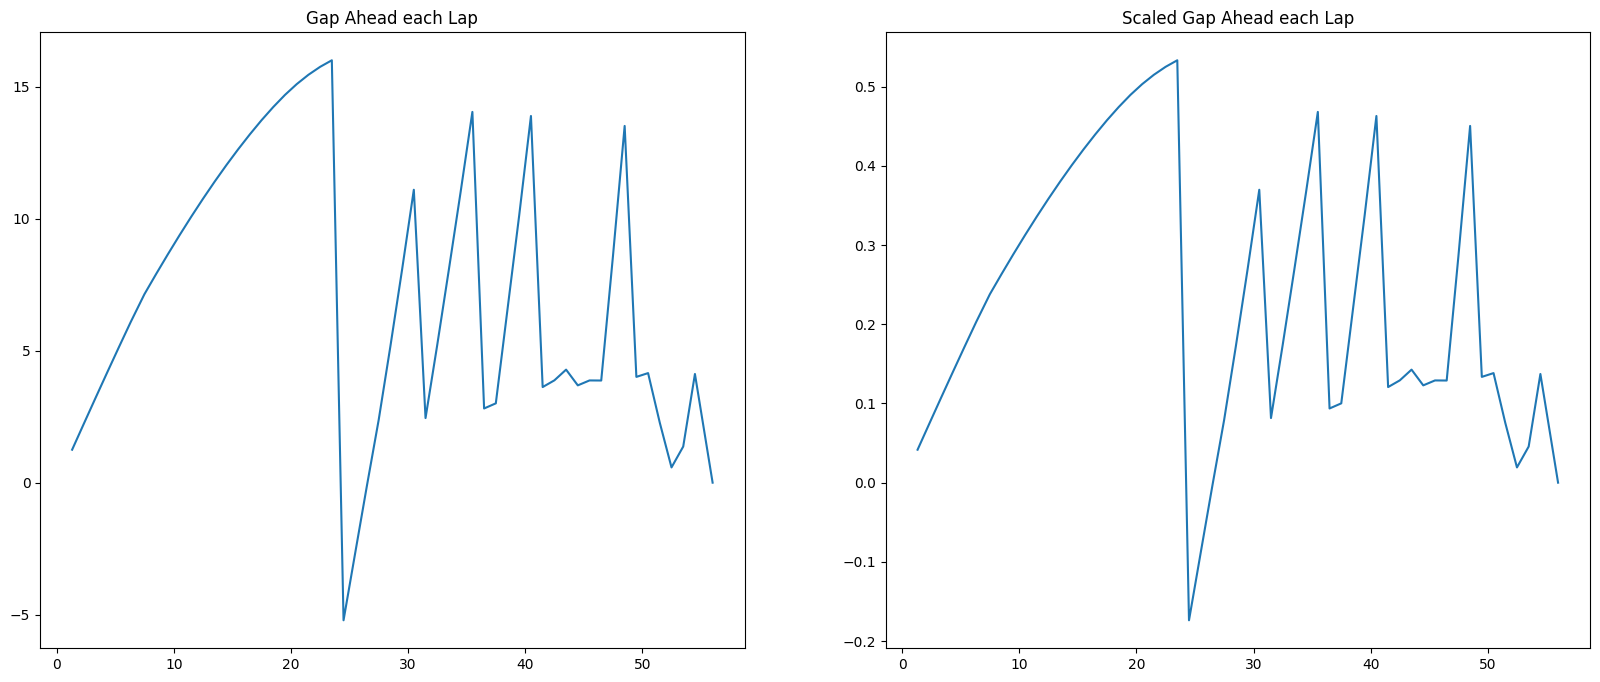

In [10]:
gap_aheads = [state.gap_ahead for state in states]
scaled_gap_aheads = [state.scaled_gap_ahead for state in states]

plot_two_graphs(gap_aheads, scaled_gap_aheads, "Gap Ahead each Lap", "Scaled Gap Ahead each Lap")


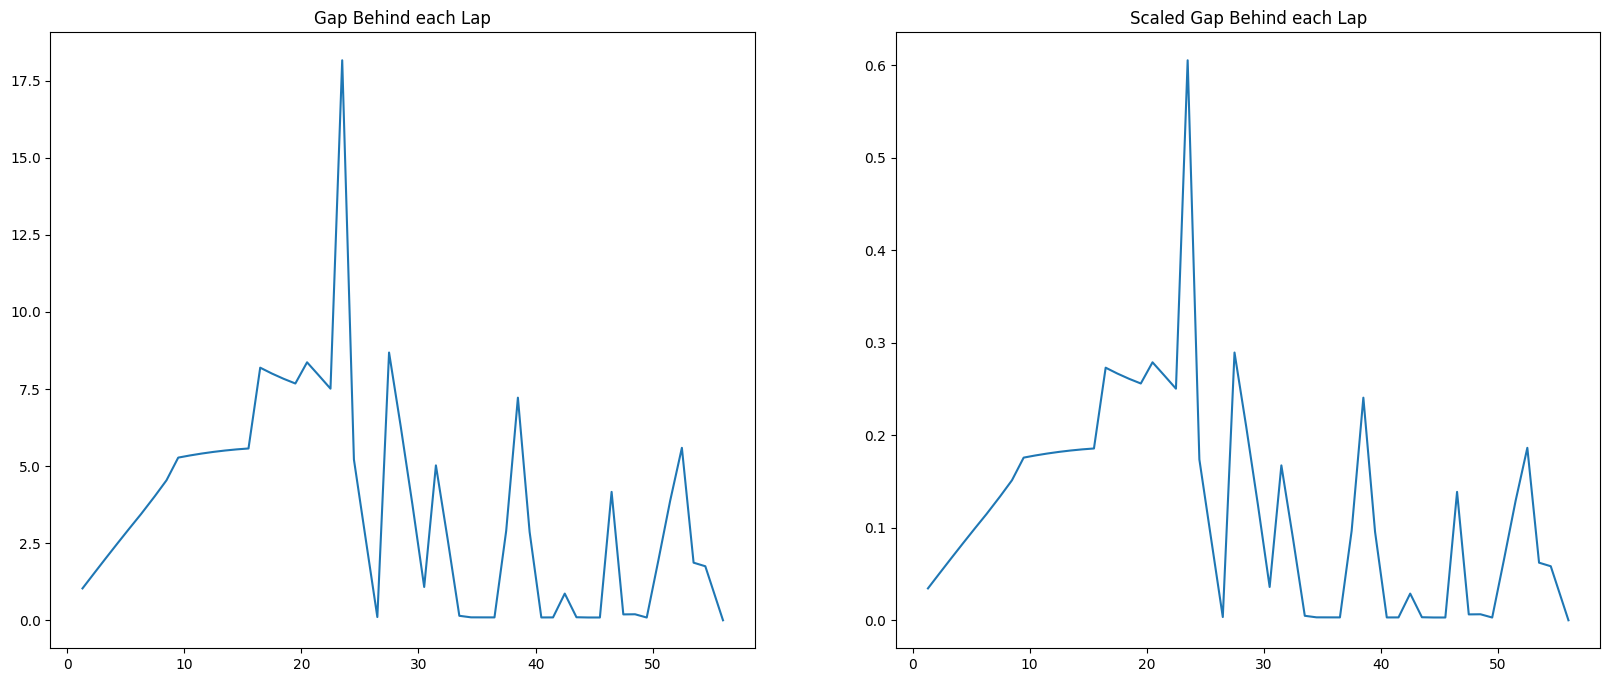

In [11]:
gap_behinds = [state.gap_behind for state in states]
scaled_gap_behinds = [state.scaled_gap_behind for state in states]

plot_two_graphs(gap_behinds, scaled_gap_behinds, "Gap Behind each Lap", "Scaled Gap Behind each Lap")

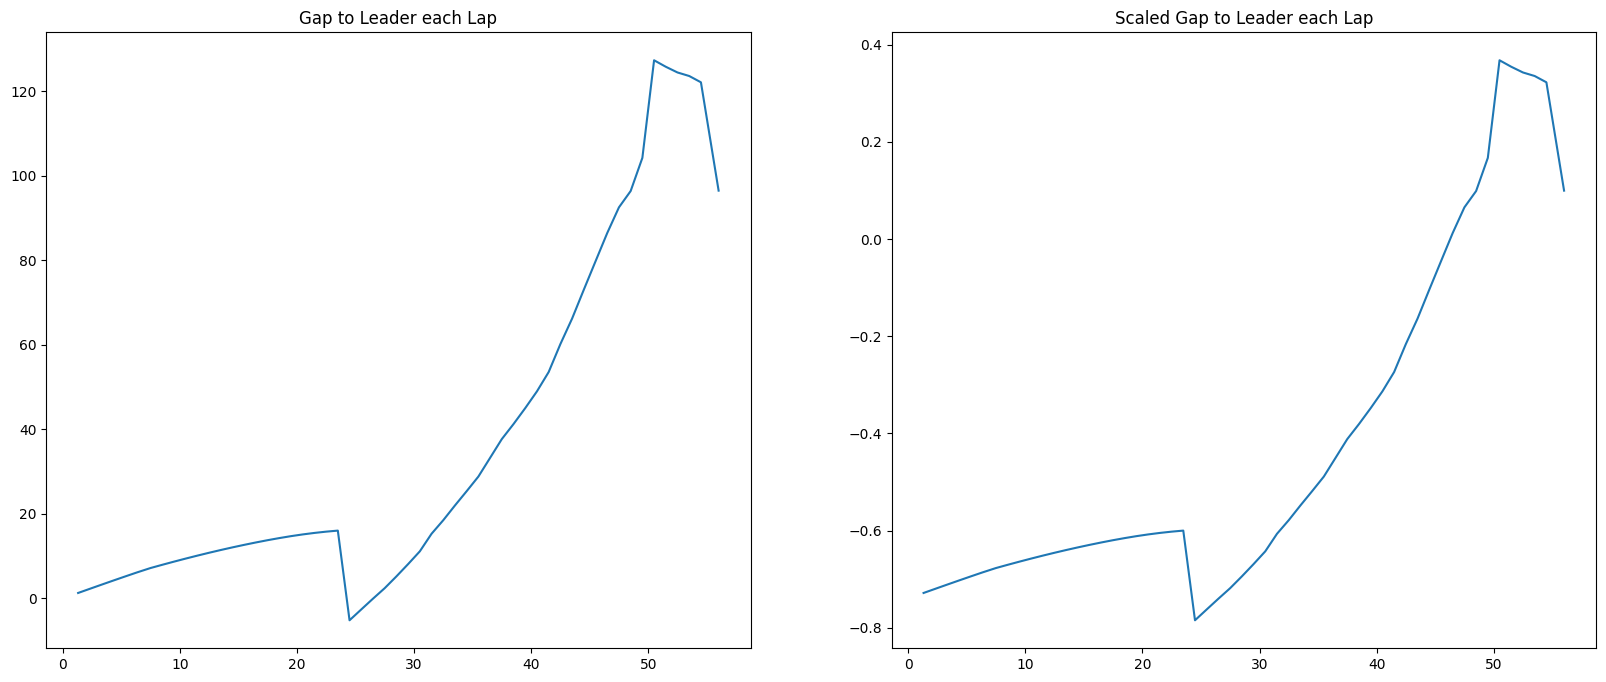

In [12]:
gap_to_leaders = [state.gap_to_leader for state in states]
scaled_gap_to_leaders = [state.scaled_gap_to_leader for state in states]

plot_two_graphs(gap_to_leaders, scaled_gap_to_leaders, "Gap to Leader each Lap", "Scaled Gap to Leader each Lap")

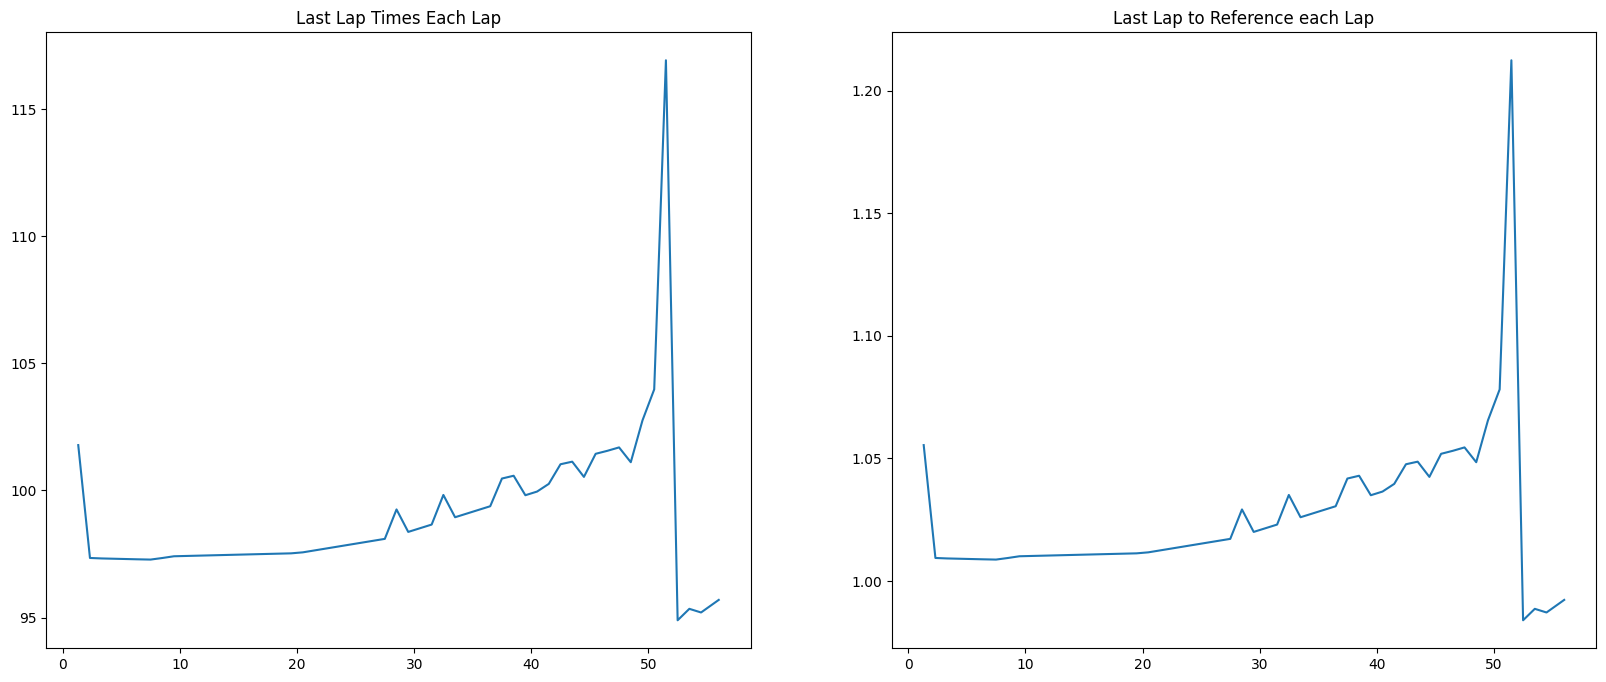

In [13]:
last_laps = [state.last_lap_time for state in states]
last_to_refs = [state.last_lap_to_reference for state in states]
plot_two_graphs(last_laps, last_to_refs, "Last Lap Times Each Lap", "Last Lap to Reference each Lap")

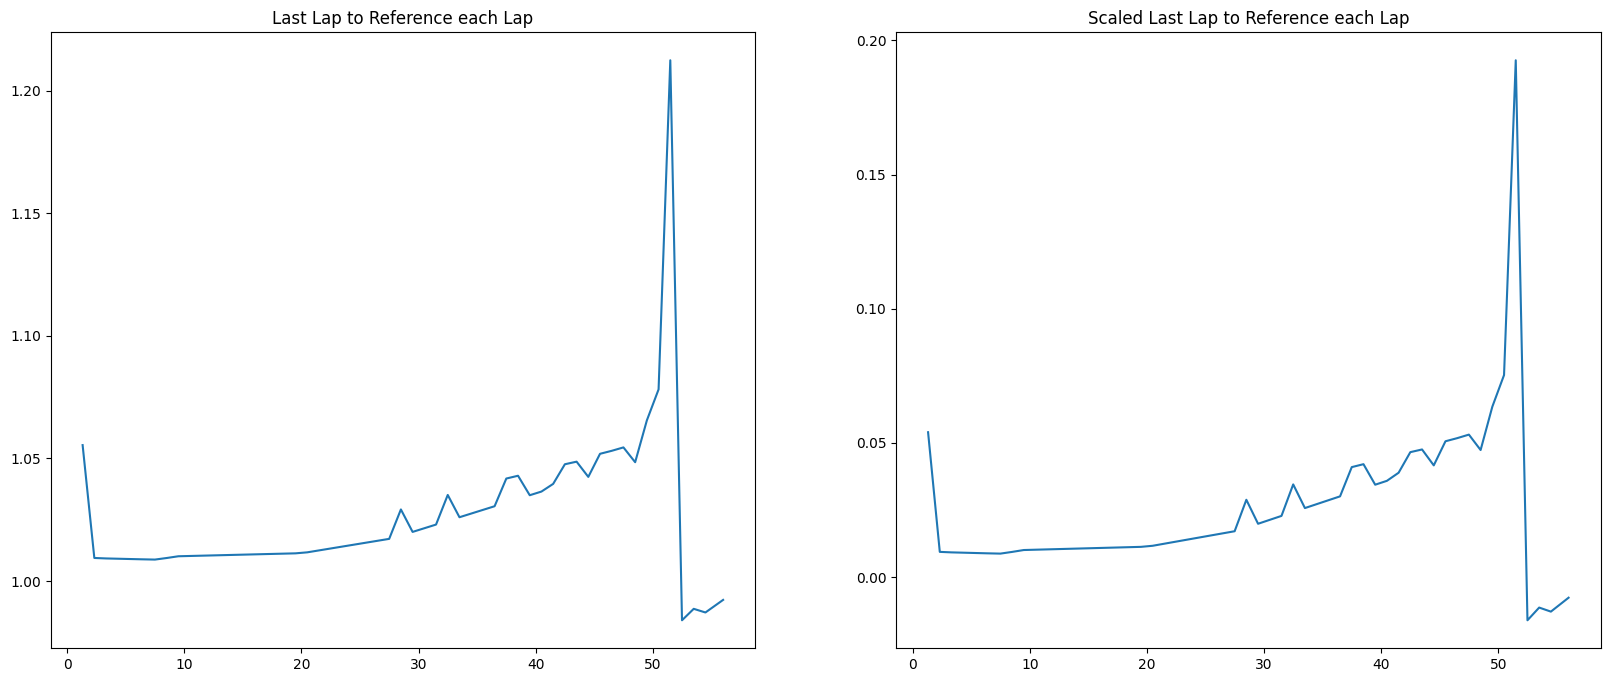

In [14]:
last_to_refs = [state.last_lap_to_reference for state in states]
scaled_last_to_refs = [state.scaled_last_lap_to_reference for state in states]
plot_two_graphs(last_to_refs, scaled_last_to_refs, "Last Lap to Reference each Lap", "Scaled Last Lap to Reference each Lap")

In [15]:
# Open expert dataset and plot scatter plots
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Datasets/features_plot_all_list.csv",true_values=["True"],false_values=["False"])
dft = pd.read_csv("Datasets/expert_dataset_tensor.csv",true_values=["True"],false_values=["False"])

def scatter_plot(
    column: str,
):
    no_pit_race_progresses = df["Race Progress"][df["Decision"] == "NO_PIT"]
    pit_soft_race_progresses = df["Race Progress"][df["Decision"] == "PIT_SOFT"]
    pit_medium_race_progresses = df["Race Progress"][df["Decision"] == "PIT_MEDIUM"]
    pit_hard_race_progresses = df["Race Progress"][df["Decision"] == "PIT_HARD"]
    
    no_pit_columns = df[column][df["Decision"] == "NO_PIT"]
    pit_soft_columns = df[column][df["Decision"] == "PIT_SOFT"]
    pit_medium_columns = df[column][df["Decision"] == "PIT_MEDIUM"]
    pit_hard_columns = df[column][df["Decision"] == "PIT_HARD"]

    plt.scatter(no_pit_race_progresses, no_pit_columns, color="black")
    plt.scatter(pit_soft_race_progresses, pit_soft_columns, color="red")
    plt.scatter(pit_medium_race_progresses, pit_medium_columns, color="yellow")
    plt.scatter(pit_hard_race_progresses, pit_hard_columns, color="grey")

    plt.title(f"{column} each Lap")
    plt.xlabel("Race Progress (%)")
    plt.ylabel(column)
    plt.show()

def barh_chart(
    column: str,
):
    df[column].value_counts().plot(kind="barh")
    
df

,Terminal,Track,Track Category,Year,Safety Car,Position,Scaled Position,Pre Pitstop Position,Predicted Finish,Partial Lap Number,...,Gap Behind,Scaled Gap Behind,Gap To Leader,Scaled Gap To Leader,Last Lap Time,Reference Lap Time,Last Lap To Reference,Scaled Last Lap To Reference,Valid Finish,Decision
0,False,BAHRAIN,CAT1,2023,NSC,3,0.105263,5,3,22.490292,...,15.886299,0.529543,14.882234,0.813394,98.227538,96.438743,1.018549,0.018379,False,PIT_HARD
1,False,BAHRAIN,CAT1,2023,NSC,3,0.105263,5,3,44.490292,...,6.700680,0.223356,20.639366,0.818575,96.907309,96.438743,1.004859,0.004847,False,PIT_MEDIUM
2,False,BAHRAIN,CAT1,2023,NSC,4,0.157895,5,4,18.490292,...,5.518484,0.183949,28.781824,0.825904,98.209941,96.438743,1.018366,0.018199,False,PIT_HARD
3,False,BAHRAIN,CAT1,2023,NSC,2,0.052632,5,2,44.490292,...,0.784099,0.026137,84.082992,0.875675,97.019582,96.438743,1.006023,0.006005,True,PIT_SOFT
4,False,BAHRAIN,CAT1,2023,NSC,5,0.210526,5,5,38.490292,...,16.271533,0.542384,35.482297,0.831934,97.172934,96.438743,1.007613,0.007584,False,PIT_HARD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
769,False,BAHRAIN,CAT1,2023,NSC,4,0.157895,5,4,14.490292,...,0.765966,0.025532,10.973347,0.809876,98.054060,96.438743,1.016750,0.016611,False,PIT_HARD
770,False,BAHRAIN,CAT1,2023,NSC,4,0.157895,5,4,41.490292,...,8.363199,0.278773,22.503338,0.820253,98.422803,96.438743,1.020573,0.020364,True,PIT_SOFT
771,False,BAHRAIN,CAT1,2023,NSC,8,0.368421,5,8,13.490292,...,1.471841,0.049061,32.335443,0.829102,98.790102,96.438743,1.024382,0.024089,False,NO_PIT
772,False,BAHRAIN,CAT1,2023,NSC,5,0.210526,5,5,17.490292,...,3.113669,0.103789,35.459586,0.831914,98.164518,96.438743,1.017895,0.017737,False,PIT_HARD


/var/folders/88/4y3_7zmd2gn0dl8_mwywd32r0000gn/T/ipykernel_3168/1302443940.py:2: FutureWarning:

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.



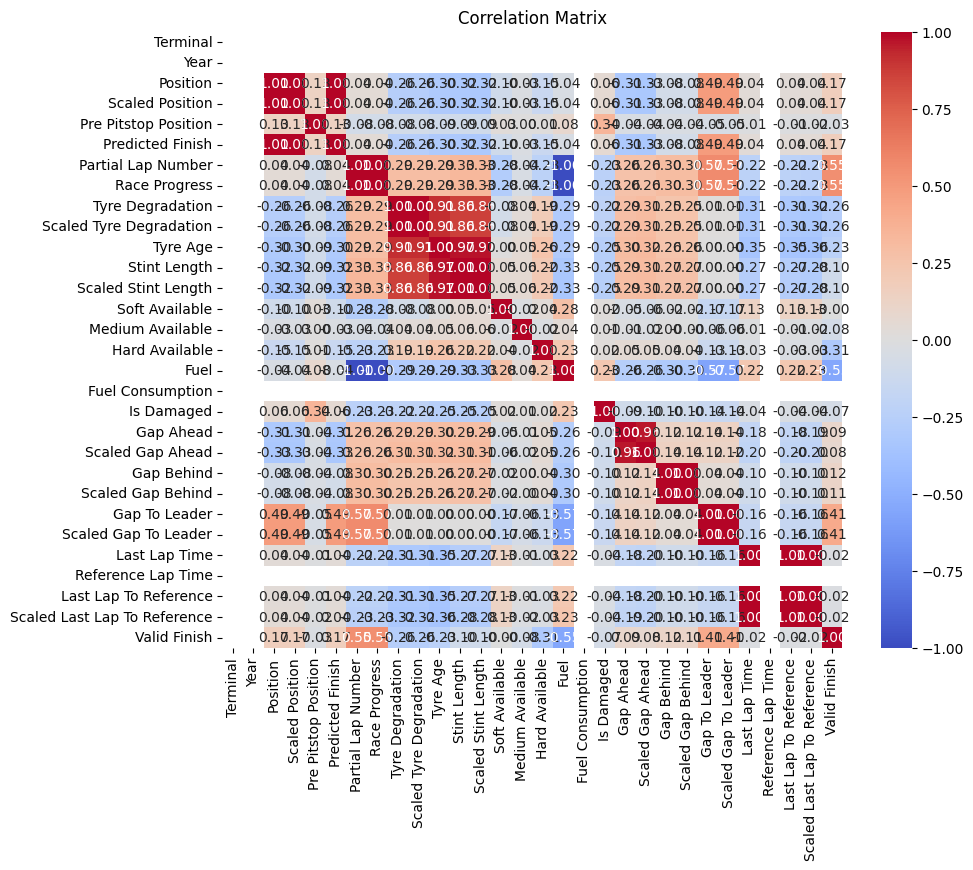

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

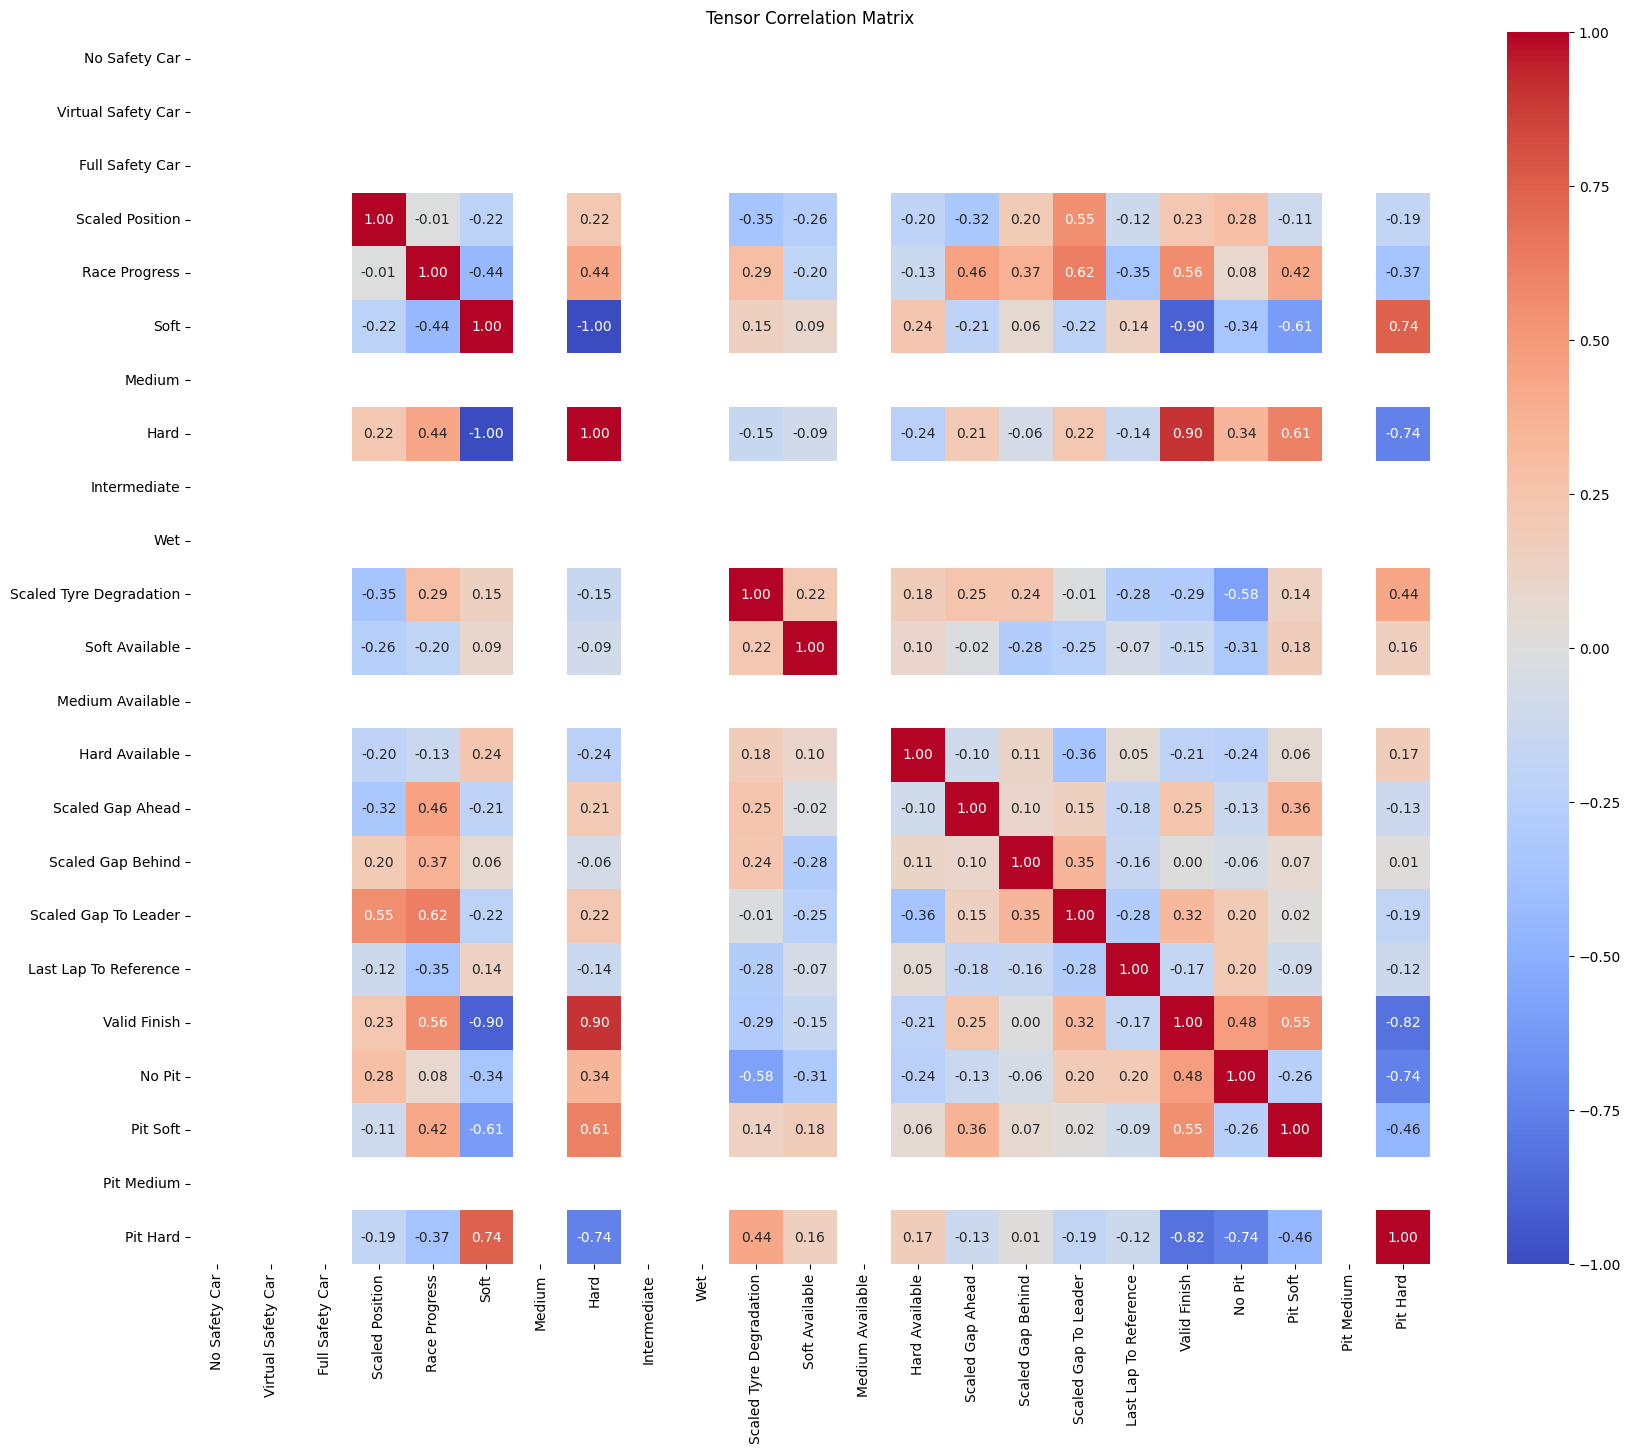

In [17]:
plt.figure(figsize=(20, 16))
sns.heatmap(dft.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Tensor Correlation Matrix')
plt.show()

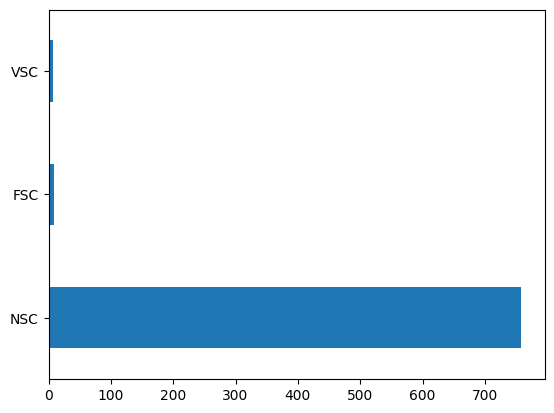

In [18]:
barh_chart("Safety Car")

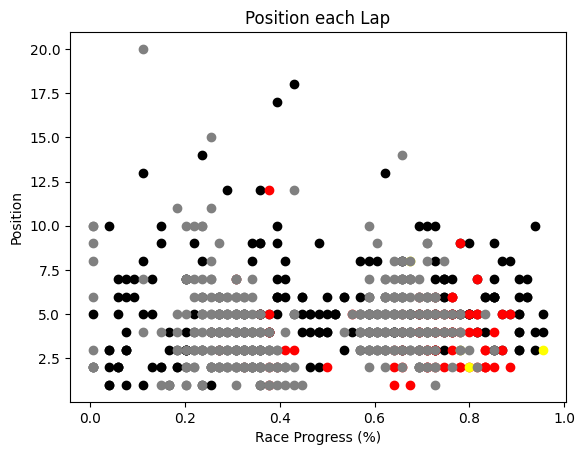

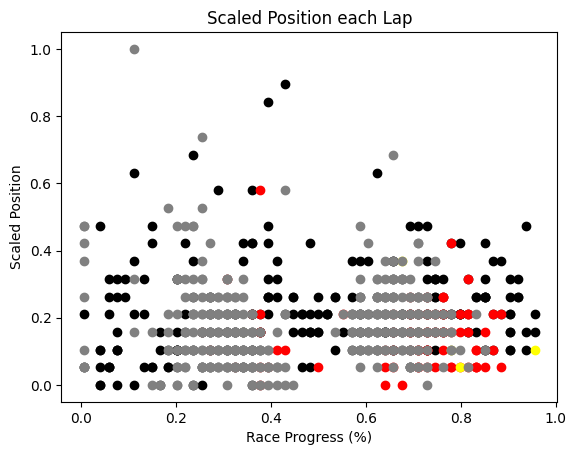

In [19]:
scatter_plot("Position")
scatter_plot("Scaled Position")

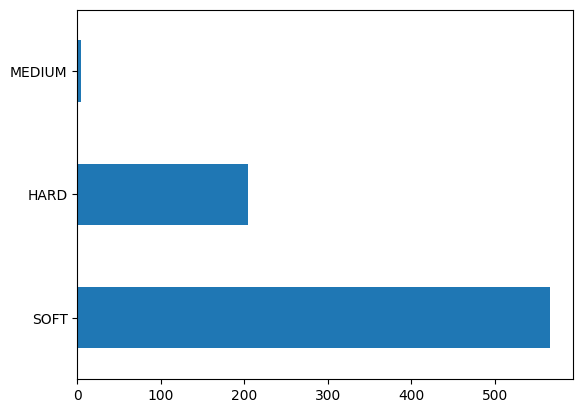

In [20]:
barh_chart("Current Tyre")

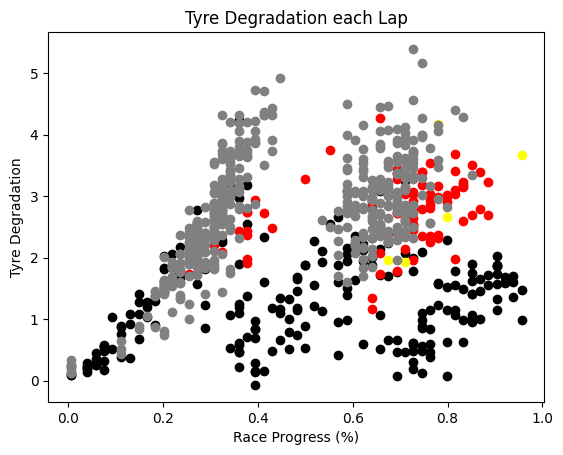

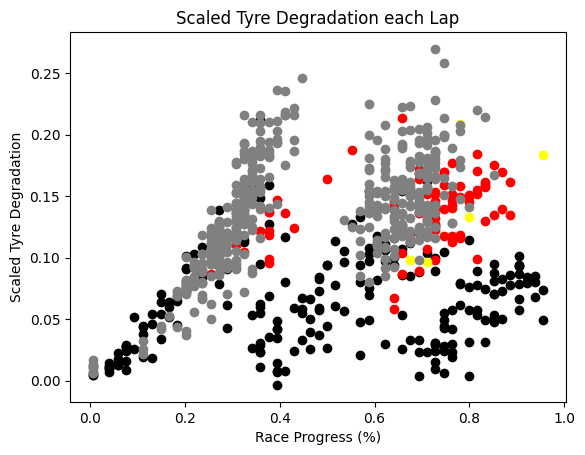

In [21]:
scatter_plot("Tyre Degradation")
scatter_plot("Scaled Tyre Degradation")

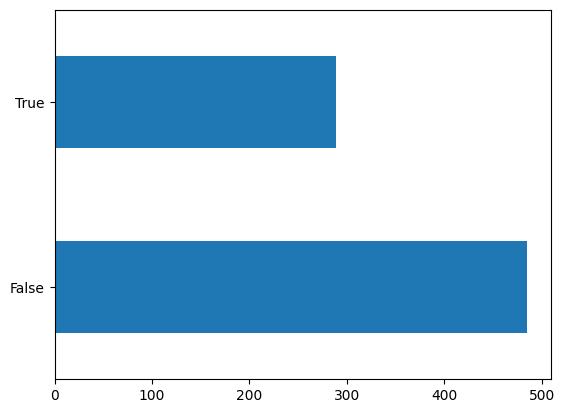

In [22]:
barh_chart("Soft Available")

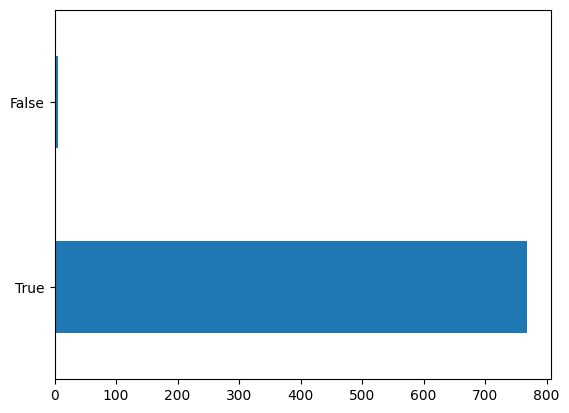

In [23]:
barh_chart("Medium Available")

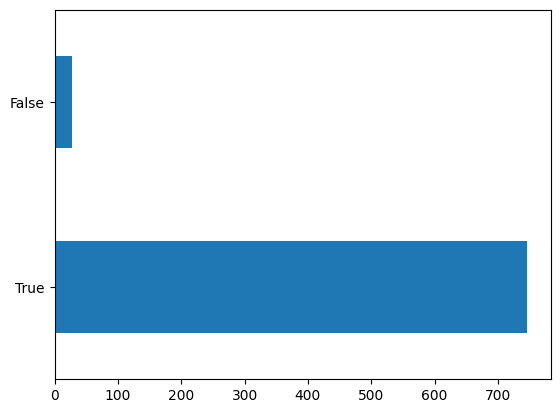

In [24]:
barh_chart("Hard Available")

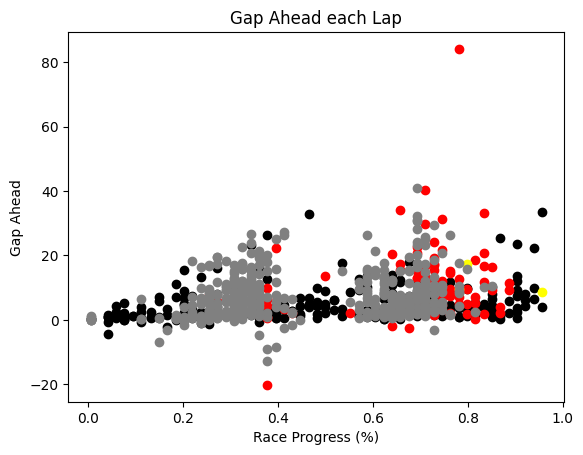

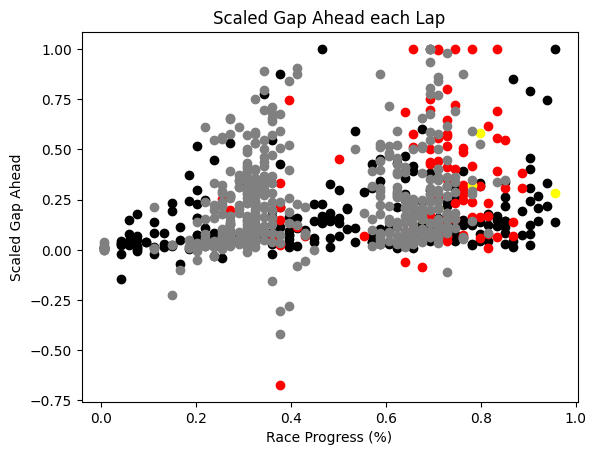

In [25]:
scatter_plot("Gap Ahead")
scatter_plot("Scaled Gap Ahead")

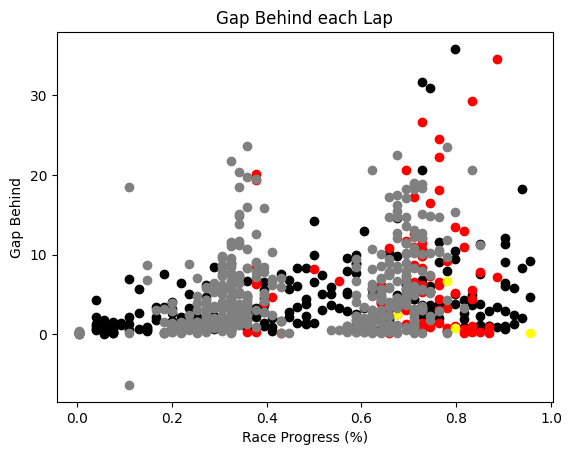

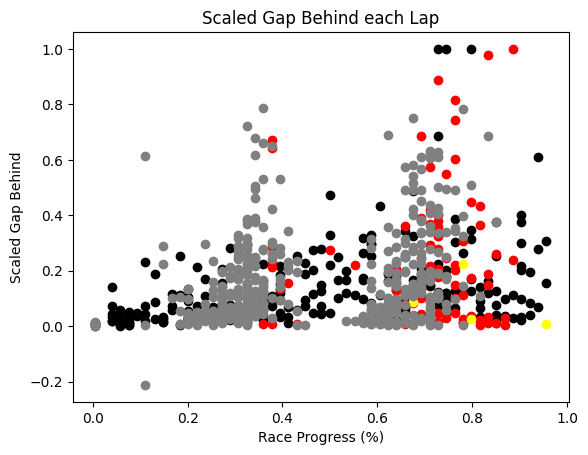

In [26]:
scatter_plot("Gap Behind")
scatter_plot("Scaled Gap Behind")

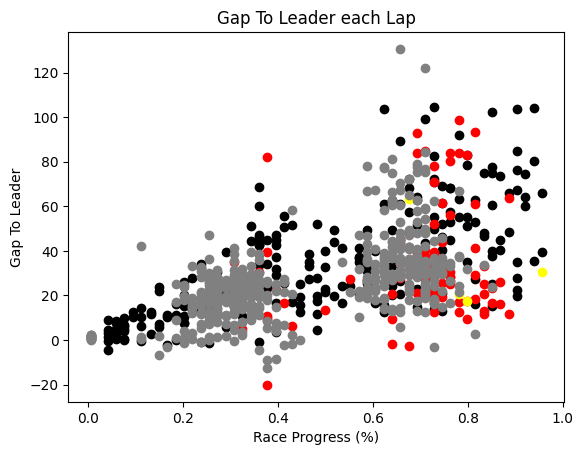

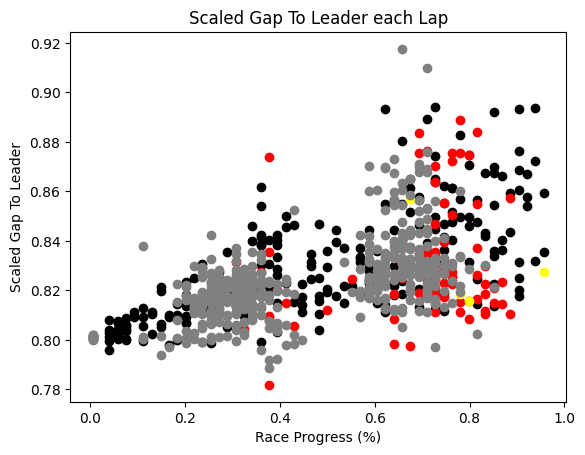

In [27]:
scatter_plot("Gap To Leader")
scatter_plot("Scaled Gap To Leader")

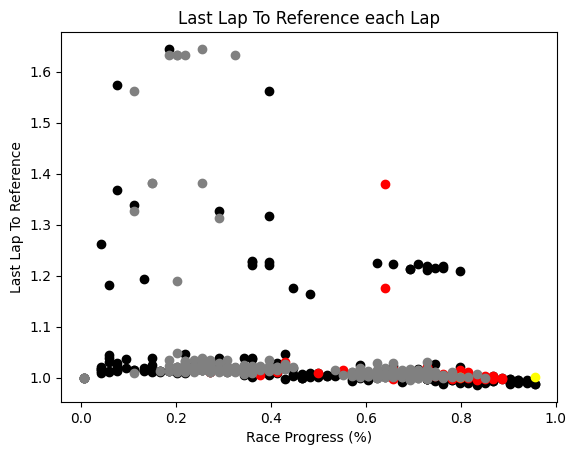

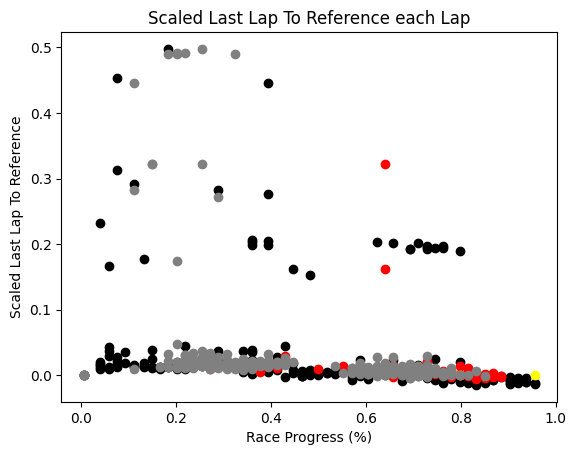

In [28]:
scatter_plot("Last Lap To Reference")
scatter_plot("Scaled Last Lap To Reference")

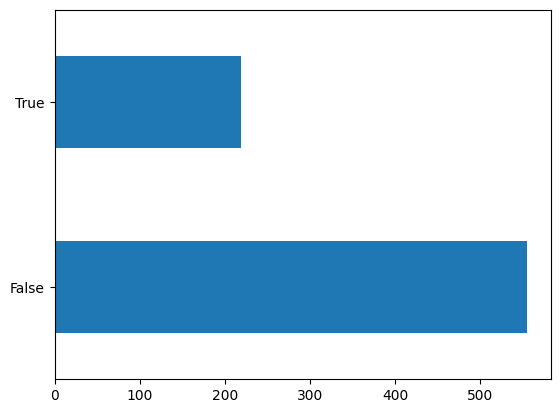

In [29]:
barh_chart("Valid Finish")

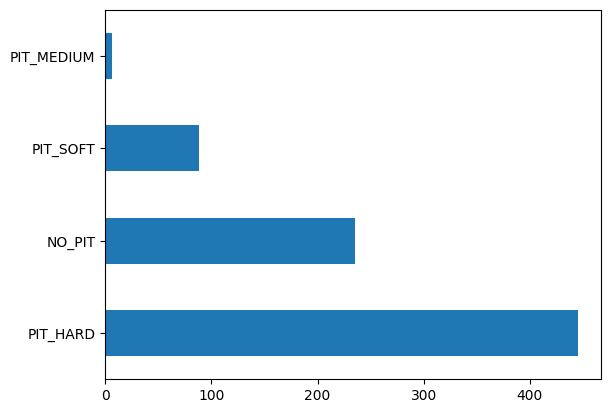

In [30]:
barh_chart("Decision")

In [31]:
# Test for erroneous data
df[df["Last Lap To Reference"] == 0.0]

,Terminal,Track,Track Category,Year,Safety Car,Position,Scaled Position,Pre Pitstop Position,Predicted Finish,Partial Lap Number,...,Gap Behind,Scaled Gap Behind,Gap To Leader,Scaled Gap To Leader,Last Lap Time,Reference Lap Time,Last Lap To Reference,Scaled Last Lap To Reference,Valid Finish,Decision


# Error Testing

In [32]:
from Classes.Enums import Track
from Classes.RaceStrategy.SimpleRaceStrategy import SimpleRaceStrategy
from confidential.MercedesRSTranslator import MercedesRSTranslator
import numpy as np
from RewardFunctions.RewardFunctions import thomas_reward_2

seed = np.random.randint(0, 1000)
sim = MercedesRSTranslator(
    selected_driver=44,
    seed=seed,
    allowed_years=["2023"],
    allowed_tracks=[Track.BAHRAIN],
    disable_safety_car=False,
    verbose=True,
)
_, state = sim.initialise_random_simulation()
print(state)

pl = 10
while not state.terminal:
    action = SimpleRaceStrategy.PIT_MEDIUM if pl < state.partial_lap_number <= pl+1 else SimpleRaceStrategy.NO_PIT
    next_state = sim.step(step=1.0, strategy=action)
    reward = thomas_reward_2(state, action, next_state)
    print(action, next_state)
    state = next_state

-------------------- SIMULATION DETAILS --------------------
Track: BAHRAIN 2023
Total Laps: 57
Seed: 874
Selected Driver: 44
Restricted Years: ['2023']
Restricted Tracks: [BAHRAIN]
------------------------------------------------------------
UnifiedRaceState[R BAHRAIN CAT1 2023 NSC P4  SP0.158  PP4  PF4  L0.32  L%0   PS0  S TD0.306  STD0.015  T%2   SL1.0  SSL0.010  [ ] [M] [H] F108.363 FC1.910  ND GA0.346   SGA0.012  GB0.608   SGB0.020  GL0.904   SGL-0.731 LL96.439   RL96.439  LT%100 SLT0.00 NV ]
NO_PIT UnifiedRaceState[R BAHRAIN CAT1 2023 NSC P6  SP0.263  PP5  PF6  L1.32  L%2   PS0  S TD0.206  STD0.010  T%4   SL2.0  SSL0.020  [ ] [M] [H] F106.453 FC1.910  ND GA1.347   SGA0.045  GB0.804   SGB0.027  GL4.760   SGL-0.698 LL104.573  RL96.439  LT%108 SLT0.08 NV ]
NO_PIT UnifiedRaceState[R BAHRAIN CAT1 2023 NSC P6  SP0.263  PP5  PF6  L2.32  L%4   PS0  S TD0.371  STD0.019  T%5   SL3.0  SSL0.030  [ ] [M] [H] F104.543 FC1.910  ND GA1.040   SGA0.035  GB1.018   SGB0.034  GL6.805   SGL-0.680 LL99

# Model Testing Plots

In [33]:
import pandas as pd

df = pd.read_csv("test_model_results.csv", keep_default_na=False)
df

,Test Run,Model Name,Track,Year,Finishing Position,Tyre Strategy
0,0,MercedesLinearModel,BAHRAIN,2023,7,S0 H17H30
1,0,MercedesLinearModel,BAHRAIN,2023,7,S0 S15H35
2,0,MercedesLinearModel,BAHRAIN,2023,12,S0 S1 S16H40
3,0,MercedesLinearModel,BAHRAIN,2023,6,S0 H19S42
4,0,MercedesLinearModel,BAHRAIN,2023,5,S0 S21H33
...,...,...,...,...,...,...
25215,67,DRQN HPT35_CP20000,BAHRAIN,2023,10,S0 H1
25216,67,DRQN HPT35_CP20000,BAHRAIN,2023,15,S0 M1
25217,67,DRQN HPT35_CP20000,BAHRAIN,2023,17,S0 M1
25218,67,DRQN HPT35_CP20000,BAHRAIN,2023,10,S0 H1


In [34]:
import Testing.testing_results_utilities as utils
import plotting as p

worker_results = utils.convert_df_to_worker_results(df)

# p.plot_race_histograms(worker_results)

IndentationError: unexpected indent (2179115793.py, line 2)

       Test Run           Model Name    Track  Year  Finishing Position  \
0             0  MercedesLinearModel  BAHRAIN  2023                   7   
1             0  MercedesLinearModel  BAHRAIN  2023                   7   
2             0  MercedesLinearModel  BAHRAIN  2023                  12   
3             0  MercedesLinearModel  BAHRAIN  2023                   6   
4             0  MercedesLinearModel  BAHRAIN  2023                   5   
...         ...                  ...      ...   ...                 ...   
16995        24   DRQN HPT14_CP12000  BAHRAIN  2023                   8   
16996        24   DRQN HPT14_CP12000  BAHRAIN  2023                   9   
16997        24   DRQN HPT14_CP12000  BAHRAIN  2023                   7   
16998        24   DRQN HPT14_CP12000  BAHRAIN  2023                   5   
16999        24   DRQN HPT14_CP12000  BAHRAIN  2023                   8   

      Tyre Strategy  
0         S0 H17H30  
1         S0 S15H35  
2      S0 S1 S16H40  
3         S

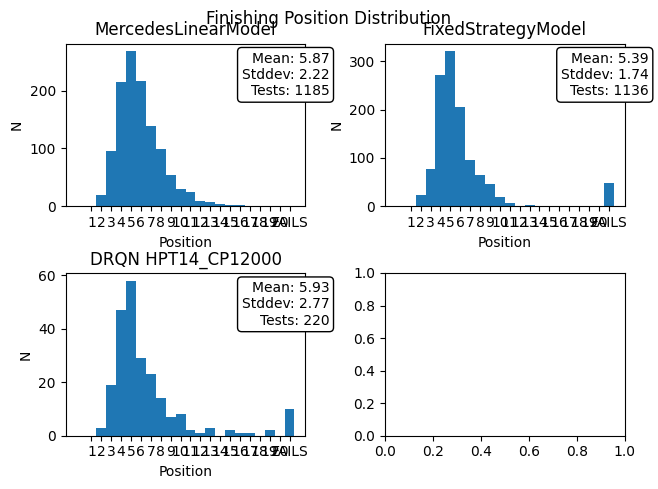

In [ ]:
# Filter out only MercedesLinearModel results
mdf = df[df["Model Name"].isin(["MercedesLinearModel", "FixedStrategyModel", "DRQN HPT14_CP12000"])]
print(mdf)
m_worker_results = utils.convert_df_to_worker_results(mdf)

p.plot_race_histograms(m_worker_results)

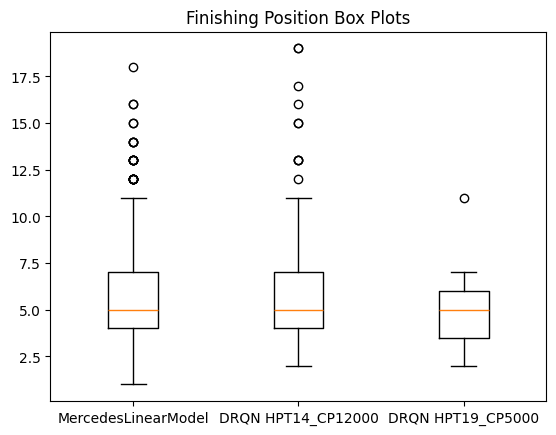

In [ ]:
def plot_box_plots(
    df: pd.DataFrame,
) -> None:
    # Get finishing position list for each model name
    model_names = df["Model Name"].unique()
    data, labels = [], []
    for model_name in model_names:
        model_df = df[df["Model Name"] == model_name]
        positions = model_df["Finishing Position"]
        positions = positions[positions != 21]
        
        data.append(positions)
        labels.append(model_name)

    plt.boxplot(data, labels=labels)
    plt.title("Finishing Position Box Plots")
    plt.show()


xdf = df[df["Model Name"].isin(["MercedesLinearModel", "DRQN HPT14_CP12000", "DRQN HPT19_CP5000"])]
plot_box_plots(xdf)